In a previous notebook I replicated Figures 11 and 12 from Sadavoy, 2019 (https://ui.adsabs.harvard.edu/abs/2019ApJS..245....2S/abstract)

I am not going to try to adapt it to work for ALMA Band 7

## Load Intro Things

In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FITS FILES/BAND5/load_band5_data.py"

In [3]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

# Image

In [4]:
StokesI_stretched_mJy, StokesI_unstretched_cbar_ticks = normalize_stokesI_for_cmap(StokesI_mJy,
                                                                                   custom_min = 0.000006 * 1000,
                                                                                   custom_max = 2)

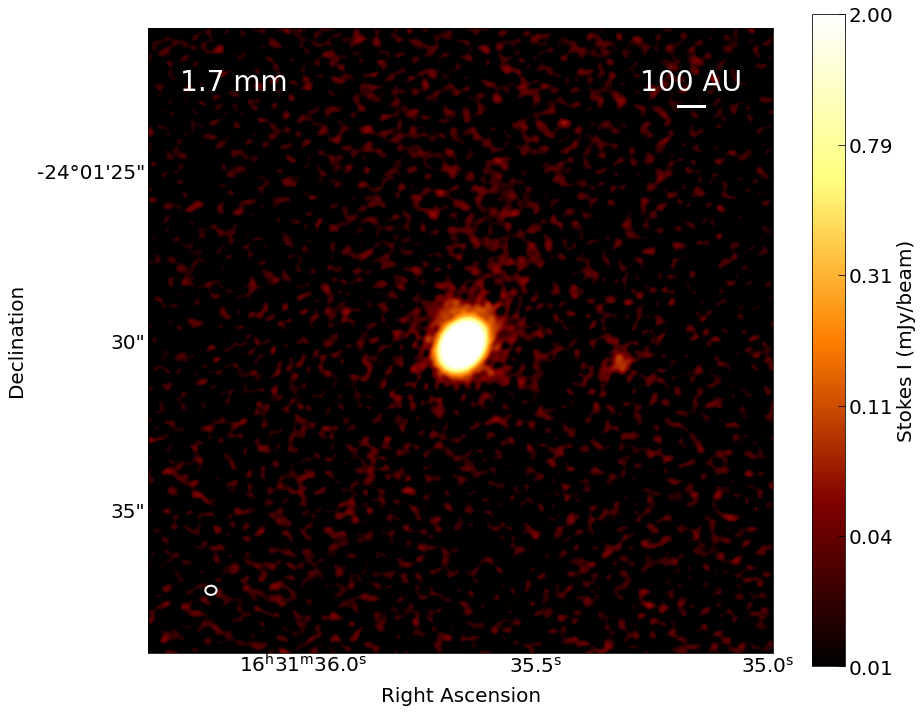

In [5]:
fig, ax = create_stokes_i_base_plot("Band 5", StokesI_wcs, StokesI_stretched_mJy, "afmhot", 
                              normalized_cbar_ticks, StokesI_unstretched_cbar_ticks, 
                              0, nx, 0, ny, 
                              reference_length_pix, reference_length_AU,
                              BMAJ_pix, BMIN_pix, BPA_deg_cartesian, 
                              max_length_pix, reference_fraction,
                             label = 'wavelength', fontcolor = 'white')

plt.savefig(writeup_image_folder_path + '/GalaxyContamination/'+ "StokesI_BAND5.pdf", 
            dpi=300, 
            bbox_inches='tight')   

## Band 7

In [6]:
# sn_array = [5, 10, 20]

sn_array = [5, 9, 20]

y_cen, x_cen, df, dfs = run_galaxy_contamination("Band 7", sn_array, spacing = 'linspace')

The Schecter function form that is being used is: dN_dS = 1.15e3 * (N0 / S0) * (S / S0)**alpha * np.exp(-S/S0)
The Schecter best-fit parameters being used are: N0 = 2.2 mJy^-1 deg^-2, S0 = 3.9 mJy, and alpha = -1.7
These values are from Chen et al. (2022)
 
The dr value is: 0.25 arcsec
 
The centre position is: (y, x) = (509, 510), and at this position pb = 1.0
 


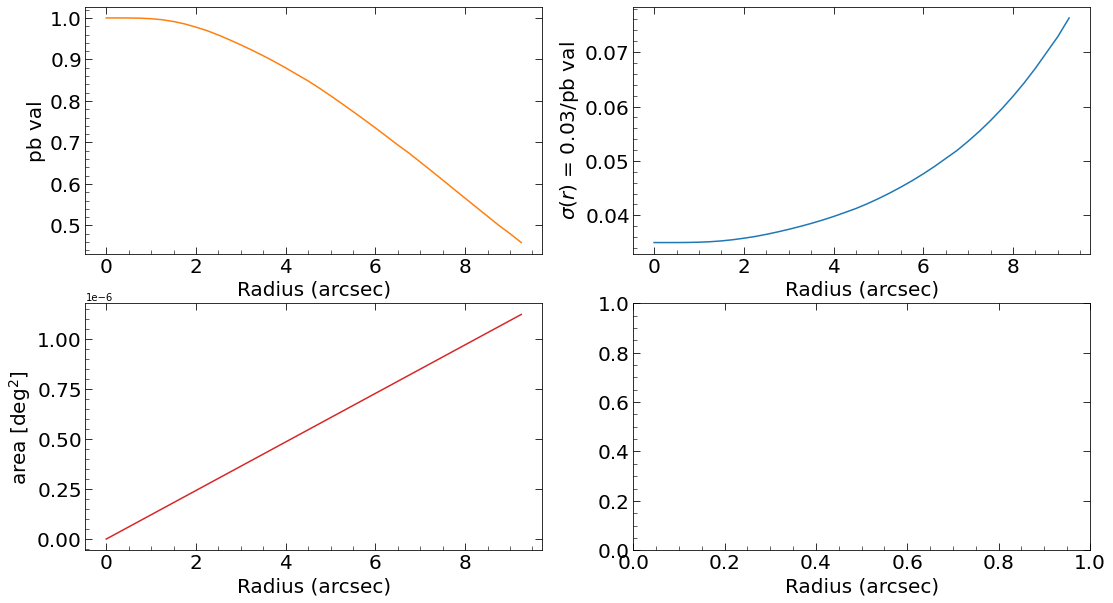

In [7]:
fig, ax = plot_galaxy_contamination_models(df)

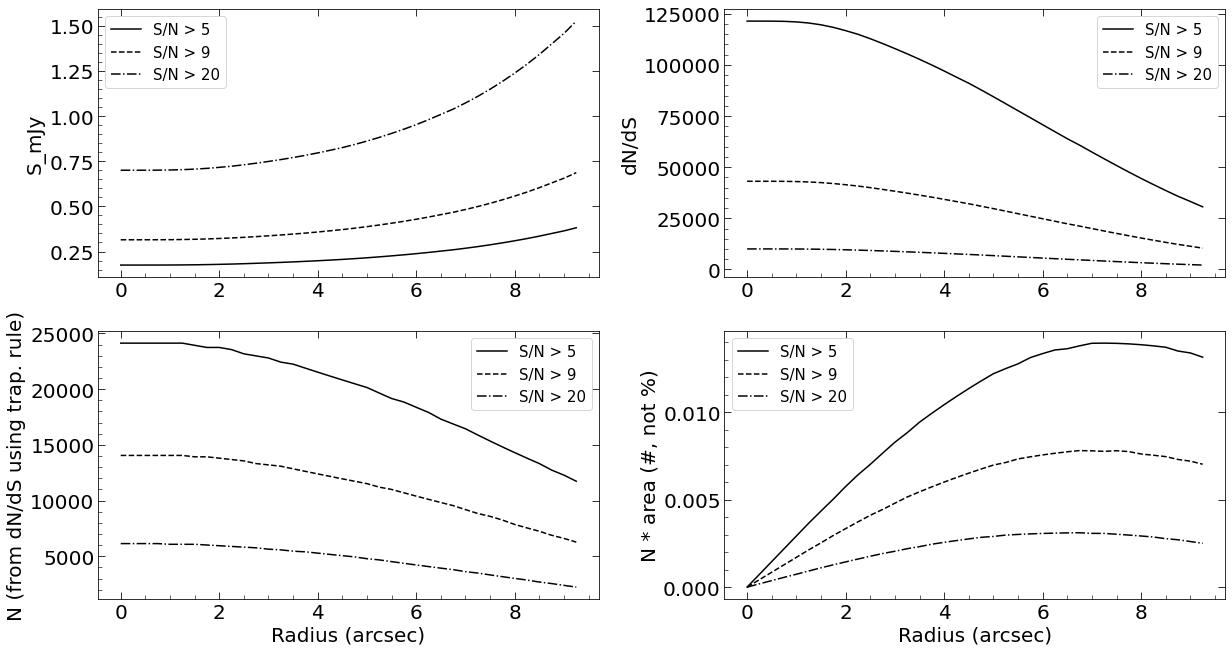

In [8]:
fig, ax = plot_probability_models(dfs, sn_array)

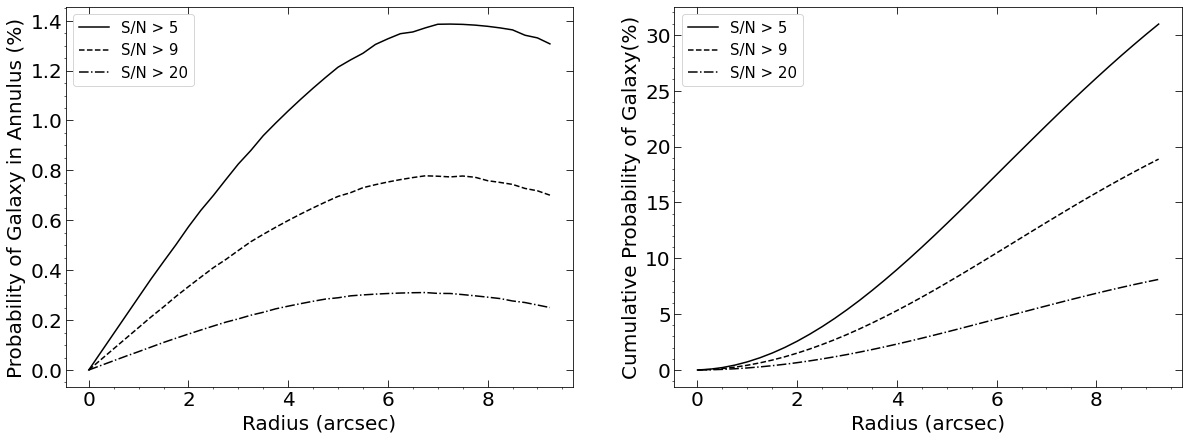

In [9]:
fig, ax = recreate_figs_11_12_sadavoy2019(dfs, sn_array)

## Find probability

In [10]:
# Check it the function way:
GC_probability(x_cen, y_cen, df, dfs, StokesI_mJy, sn_array, "Band 7", distance = "x", print_things = True)

S/N =  9.425532848222701


'The inputted values of Stokes I and the indexed ones do not match within the tolerence'

In [11]:
# adjust sample so its not wonky 